### Importando as bibliotecas

In [2327]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Carregando os dados

In [2328]:
stats_df = pd.read_csv('..\\data\\player-stats.csv', index_col=0)

### Limpeza e preparação dos dados

In [2329]:
stats_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 761 entries, 1 to 761
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  761 non-null    str    
 1   Nation  761 non-null    str    
 2   Pos     761 non-null    str    
 3   Squad   761 non-null    str    
 4   Age     761 non-null    int64  
 5   Born    761 non-null    int64  
 6   MP      761 non-null    int64  
 7   Starts  761 non-null    int64  
 8   Min     761 non-null    int64  
 9   90s     761 non-null    float64
 10  Gls     761 non-null    int64  
 11  Ast     761 non-null    int64  
 12  G+A     761 non-null    int64  
 13  G-PK    761 non-null    int64  
 14  PK      761 non-null    int64  
 15  PKatt   761 non-null    int64  
 16  CrdY    761 non-null    int64  
 17  CrdR    761 non-null    int64  
 18  2CrdY   761 non-null    int64  
 19  Fls     761 non-null    int64  
 20  Fld     761 non-null    int64  
 21  Off     761 non-null    int64  
 22  Crs     761 n

In [2330]:
stats_df.describe()

,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,...,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG
count,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,...,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,0.0,0.0,761.000000
mean,25.932983,1998.160315,15.766097,10.985545,985.625493,10.951511,1.229961,0.852825,2.082786,1.111695,...,0.039422,13.814717,13.102497,1.501971,18.465177,8.162943,10.462549,NaN,NaN,0.030223
std,5.269023,5.276617,10.684369,10.165398,856.659389,9.519151,2.384367,1.533622,3.463301,2.103101,...,0.207800,13.449656,15.334430,3.017983,31.192343,9.840290,11.724535,NaN,NaN,0.171314
min,15.000000,1980.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
25%,22.000000,1994.000000,6.000000,2.000000,249.000000,2.800000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN,0.000000
50%,26.000000,1998.000000,15.000000,8.000000,791.000000,8.800000,0.000000,0.000000,1.000000,0.000000,...,0.000000,10.000000,8.000000,0.000000,5.000000,4.000000,6.000000,NaN,NaN,0.000000
75%,30.000000,2002.000000,25.000000,17.000000,1499.000000,16.700000,1.000000,1.000000,3.000000,1.000000,...,0.000000,21.000000,18.000000,2.000000,23.000000,12.000000,16.000000,NaN,NaN,0.000000
max,44.000000,2009.000000,38.000000,38.000000,3420.000000,38.000000,21.000000,14.000000,32.000000,20.000000,...,2.000000,75.000000,111.000000,33.000000,206.000000,61.000000,76.000000,NaN,NaN,1.000000


In [2331]:
stats_df = stats_df.drop(columns=['PKwon', 'PKcon'])

In [2332]:
stats_df[stats_df[['Player', 'Nation', 'Pos', 'Born']].duplicated(keep=False)]

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
Rk,,,,,,,,,,,,,,,,,,,,,
92,Pedro Borges,br BRA,MF,Fortaleza,27,1997,1,0,37,0.4,...,2,1,1,3,0,0,0,0,1,0
93,Pedro Borges,br BRA,MF,Sport Recife,27,1997,13,4,508,5.6,...,5,0,0,11,11,0,0,7,9,0
168,Lautaro Díaz,ar ARG,FW,Santos,26,1998,15,12,1020,11.3,...,2,0,0,17,9,5,7,3,2,0
169,Lautaro Díaz,ar ARG,FW,Cruzeiro,26,1998,6,0,85,0.9,...,0,0,0,0,0,0,2,0,0,0
186,Carlos Eduardo,br BRA,FWMF,Mirassol,28,1996,24,5,734,8.2,...,2,0,0,18,24,5,27,5,8,0
187,Carlos Eduardo,br BRA,FWMF,Vitória,28,1996,2,0,41,0.5,...,0,0,0,0,1,0,3,1,0,0
236,Gabriel,br BRA,GK,Vitória,32,1992,1,1,90,1.0,...,0,0,0,0,1,0,0,0,0,0
238,Gabriel,br BRA,GK,Sport Recife,32,1992,23,23,2070,23.0,...,3,0,0,0,4,0,0,0,0,0
297,Victor Hugo,br BRA,MF,Santos,20,2004,9,6,443,4.9,...,0,0,0,3,3,0,7,2,2,0


##### Agregando linhas de jogadores iguais que jogaram por dois times diferentes durante a temporada

In [2333]:
# Tirando as colunas que envolvam algum tipo de cálculo

stats_df = stats_df.drop(columns=['Age', '90s', 'G+A', 'G-PK'])

In [2334]:
stats_df.shape

(761, 22)

In [2335]:
agg_dict = {
    'Player': 'first',
    'Nation': 'first',
    'Pos': 'first',
    'Squad': lambda x: ' / '.join(x.unique()),
    'Born': 'first',
    'MP': 'sum',
    'Starts': 'sum',
    'Min': 'sum',
    'Gls': 'sum',
    'Ast': 'sum',
    'PK': 'sum',
    'PKatt': 'sum',
    'CrdY': 'sum',
    'CrdR': 'sum',
    '2CrdY': 'sum',
    'Fls': 'sum',
    'Fld': 'sum',
    'Off': 'sum',
    'Crs': 'sum',
    'Int': 'sum',
    'TklW': 'sum',
    'OG': 'sum',
}

In [2336]:
stats_df = stats_df.groupby(['Player', 'Nation', 'Pos', 'Born'], as_index=False).agg(agg_dict)

In [2337]:
stats_df[stats_df[['Player', 'Nation', 'Pos', 'Born']].duplicated(keep=False)]

,Player,Nation,Pos,Squad,Born,MP,Starts,Min,Gls,Ast,...,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG


In [2338]:
stats_df[stats_df['Player'] == 'Juan Sforza']

,Player,Nation,Pos,Squad,Born,MP,Starts,Min,Gls,Ast,...,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
375,Juan Sforza,ar ARG,MF,Juventude / Vasco da Gama,2002,10,3,343,0,0,...,0,0,0,5,4,0,1,3,5,0


##### Analisando a minutagem dos jogadores para ver se vale a pena aplicar um filtro de minutagem mínima para os jogadores

<Axes: xlabel='Min', ylabel='Count'>

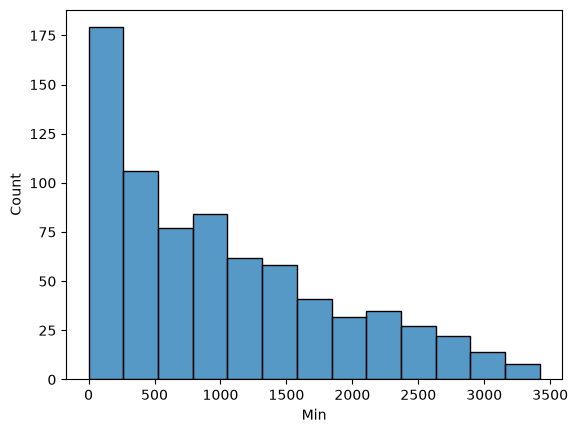

In [2339]:
sns.histplot(data=stats_df, x='Min')

In [2340]:
stats_df[stats_df['Min'] < 90]

,Player,Nation,Pos,Squad,Born,MP,Starts,Min,Gls,Ast,...,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
3,Aderlan Silva,br BRA,DF,Santos,1990,2,1,87,0,0,...,0,0,0,1,2,1,1,1,0,0
21,Alejandro Martínez,ar ARG,FWMF,Ceará,1997,2,0,49,0,1,...,0,0,0,2,1,0,2,1,1,0
34,Alisson Rodrigues,br BRA,DF,Internacional,2008,1,0,26,0,0,...,0,1,0,2,0,0,0,0,1,0
59,Bahia,br BRA,MF,Corinthians,2006,2,1,49,0,0,...,0,0,0,0,1,0,0,2,2,0
64,Bernardo,br BRA,DF,Juventude,2005,1,1,45,0,0,...,0,0,0,1,0,0,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
710,Wanderson Junior,br BRA,DF,Flamengo,2007,1,0,22,0,0,...,0,0,0,0,0,0,0,0,0,0
712,Wendell,br BRA,MF,Vitória,2005,1,1,66,0,0,...,0,0,0,0,2,0,0,1,1,0
725,Yago,br BRA,FW,Internacional,2007,2,0,73,0,0,...,0,0,0,1,0,0,5,0,1,0
733,Zé Guilherme,br BRA,DF,Bahia,2005,3,0,86,0,0,...,0,0,0,1,2,0,1,2,0,0


In [2341]:
stats_df['Min'].median()

np.float64(825.0)

In [2342]:
# Deixei a minutagem em mínima em 450 que é equivalente a 5 partidas completas de 90 minutos.

stats_df = stats_df[stats_df['Min'] > 450]

In [2343]:
stats_df['Min'].median()

np.float64(1302.5)

In [2344]:
### Refazendo as colunas de cálculo (principalmente 90s) para que posteriomente eu consiga fazer o cálculo de G/90, A/90, etc.

stats_df['90s'] = (stats_df['Min'] / 90).round(1)

### Construindo a matriz de features

In [2345]:
stats_df.columns

Index(['Player', 'Nation', 'Pos', 'Squad', 'Born', 'MP', 'Starts', 'Min',
       'Gls', 'Ast', 'PK', 'PKatt', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld',
       'Off', 'Crs', 'Int', 'TklW', 'OG', '90s'],
      dtype='str')

In [2346]:
colunas_contexto = ['Player', 'Nation', 'Pos', 'Squad', 'Born', 'MP', 'Starts', 'Min', '90s']

coluna_target = ['Pos']

colunas_evento = ['Gls', 'Ast', 'PK', 'PKatt', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'OG']

,% de zeros,assimetria (skew),z-score máximo,classificação
2CrdY,95.0,7.0,9.6,rara -> fora do KMeans
OG,95.6,6.3,10.1,rara -> fora do KMeans
PK,89.5,4.4,7.7,rara -> fora do KMeans
PKatt,88.5,3.9,6.7,rara -> fora do KMeans
CrdR,84.1,2.9,5.0,mantida
Off,40.2,2.4,5.6,mantida
Gls,39.7,2.2,6.6,mantida
Ast,47.9,1.8,4.5,mantida
Crs,12.6,1.2,3.5,mantida
CrdY,8.4,1.1,5.8,mantida


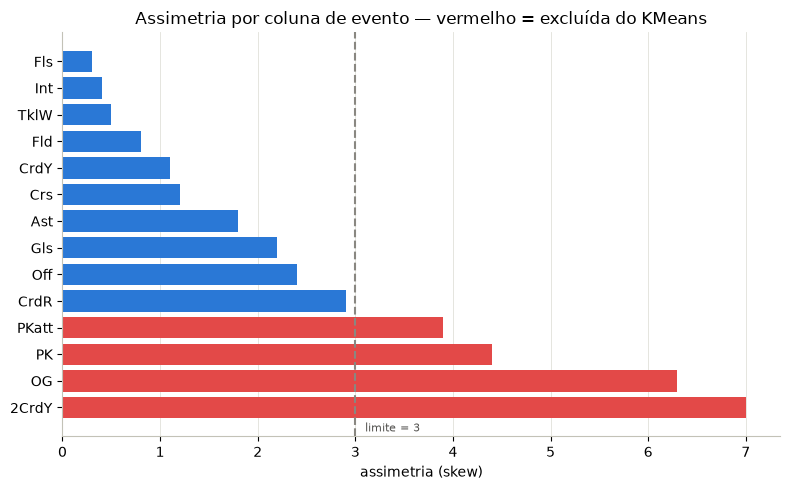

In [2347]:
_por90 = stats_df[colunas_evento].div(stats_df['90s'], axis=0)
_z = pd.DataFrame(StandardScaler().fit_transform(_por90), columns=colunas_evento)

diagnostico = pd.DataFrame({
    '% de zeros': (100 * (_por90 == 0).mean()).round(1),
    'assimetria (skew)': _por90.skew().round(1),
    'z-score máximo': _z.abs().max().round(1),
}).sort_values('assimetria (skew)', ascending=False)

diagnostico['classificação'] = np.where(
    diagnostico['assimetria (skew)'] > 3, 'rara -> fora do KMeans', 'mantida'
)

display(diagnostico)

# --- Mesma informação em gráfico: skew por coluna, com o limite de 5 marcado ---
cores_diagnostico = diagnostico['classificação'].map(
    {'rara -> fora do KMeans': '#e34948', 'mantida': '#2a78d6'}
)

plt.figure(figsize=(8, 5))
plt.barh(diagnostico.index, diagnostico['assimetria (skew)'], color=cores_diagnostico)
plt.axvline(3, color='#898781', linestyle='--', linewidth=1.5)
plt.text(3.1, -0.9, 'limite = 3', fontsize=8, color='#52514e')
plt.xlabel('assimetria (skew)')
plt.title('Assimetria por coluna de evento — vermelho = excluída do KMeans')

ax = plt.gca()
ax.grid(True, axis='x', color='#e1e0d9', linewidth=0.6)
ax.set_axisbelow(True)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
for lado in ('left', 'bottom'):
    ax.spines[lado].set_color('#c3c2b7')

plt.tight_layout()
plt.show()

del _por90, _z

In [2348]:
colunas_raras = ['PK', 'PKatt', '2CrdY', 'OG', 'CrdR']

colunas_features = [c for c in colunas_evento if c not in colunas_raras]

print(f'{len(colunas_features)} features no KMeans: {colunas_features}')

9 features no KMeans: ['Gls', 'Ast', 'CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW']


In [2349]:
stats_df.isnull().sum()

Player    0
Nation    0
Pos       0
Squad     0
Born      0
MP        0
Starts    0
Min       0
Gls       0
Ast       0
PK        0
PKatt     0
CrdY      0
CrdR      0
2CrdY     0
Fls       0
Fld       0
Off       0
Crs       0
Int       0
TklW      0
OG        0
90s       0
dtype: int64

In [ ]:
stats_df[colunas_evento] = stats_df[colunas_evento].div(stats_df['90s'], axis=0).round(2)

In [2351]:
stats_df.isnull().sum()

Player    0
Nation    0
Pos       0
Squad     0
Born      0
MP        0
Starts    0
Min       0
Gls       0
Ast       0
PK        0
PKatt     0
CrdY      0
CrdR      0
2CrdY     0
Fls       0
Fld       0
Off       0
Crs       0
Int       0
TklW      0
OG        0
90s       0
dtype: int64

In [2352]:
stats_df

,Player,Nation,Pos,Squad,Born,MP,Starts,Min,Gls,Ast,...,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG,90s
0,Abner,br BRA,DF,Juventude,2004,19,13,1318,0.00,0.07,...,0.00,0.0,1.10,0.34,0.07,0.00,1.23,0.75,0.0,14.6
1,Adam Bareiro,py PAR,FW,Fortaleza,1996,21,10,886,0.71,0.20,...,0.10,0.0,3.27,2.35,0.20,0.20,0.00,1.02,0.0,9.8
2,Ademir Santos,br BRA,FWMF,Bahia,1995,30,26,1971,0.09,0.27,...,0.00,0.0,1.23,2.37,0.27,5.02,0.23,1.05,0.0,21.9
4,Aderlan Silva,br BRA,DFMF,Sport Recife,1990,14,10,920,0.00,0.00,...,0.00,0.0,1.57,1.08,0.10,2.75,1.37,0.69,0.0,10.2
5,Adonis Frías,ar ARG,DF,Santos,1998,13,12,1112,0.00,0.00,...,0.00,0.0,1.45,0.48,0.00,0.16,1.37,0.81,0.0,12.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740,Álvaro Montoro,ar ARG,MF,Botafogo–RJ,2007,16,10,936,0.29,0.29,...,0.00,0.0,0.96,1.15,0.00,1.25,1.25,1.54,0.0,10.4
741,Ángel Romero,py PAR,FWMF,Corinthians,1992,27,11,1068,0.00,0.08,...,0.08,0.0,1.01,2.02,0.50,2.18,0.59,1.09,0.0,11.9
742,Éverson,br BRA,GK,Atlético Mineiro,1990,36,36,3240,0.00,0.00,...,0.00,0.0,0.00,0.17,0.00,0.00,0.06,0.00,0.0,36.0
743,Ênio,br BRA,MFFW,Juventude,2001,26,8,1108,0.24,0.00,...,0.00,0.0,0.65,2.76,0.49,2.44,0.08,0.33,0.0,12.3


### Aplicando o StandardScaler

In [2353]:
stats_df = stats_df[stats_df['Pos'] != 'GK']

In [2354]:
X = stats_df[colunas_features]
y = stats_df[coluna_target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### PCA

In [2355]:
### Projeção nas duas primeiras componentes (só para visualização — o KMeans continua rodando em X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
variancia = 100 * pca.explained_variance_ratio_

print(f'PC1: {variancia[0]:.1f}%  |  PC2: {variancia[1]:.1f}%')
print(f'Variância representada no plano PC1 x PC2: {variancia.sum():.1f}%')

PC1: 30.4%  |  PC2: 18.9%
Variância representada no plano PC1 x PC2: 49.2%


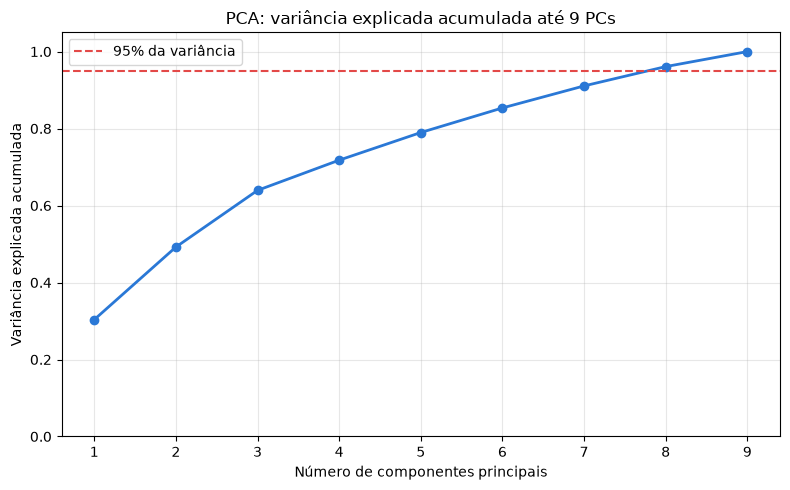

In [2356]:
### Variância explicada acumulada por todas as componentes principais

k = X_scaled.shape[1]  # uma PC por feature em colunas_features

pca_k = PCA(n_components=k)
pca_k.fit(X_scaled)

variancia_acumulada = np.cumsum(pca_k.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, k + 1),
    variancia_acumulada,
    marker='o',
    color='#2a78d6',
    linewidth=2
)

plt.axhline(
    0.95,
    color='#e34948',
    linestyle='--',
    linewidth=1.5,
    label='95% da variância'
)

plt.xticks(range(1, k + 1))
plt.ylim(0, 1.05)
plt.xlabel('Número de componentes principais')
plt.ylabel('Variância explicada acumulada')
plt.title(f'PCA: variância explicada acumulada até {k} PCs')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Aplicando o Kmeans e escolhendo o K

In [2357]:
### Rodando o KMeans para k de 2 a 10, guardando a inércia de cada um

valores_k = range(2, 11)
inercias = []

for k in valores_k:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

metricas = pd.DataFrame({
    'k': list(valores_k),
    'inercia': inercias,
})

display(metricas.round(3))

,k,inercia
0,2,3103.822
1,3,2748.815
2,4,2457.216
3,5,2317.301
4,6,2196.349
5,7,2087.633
6,8,2003.142
7,9,1948.649
8,10,1862.078


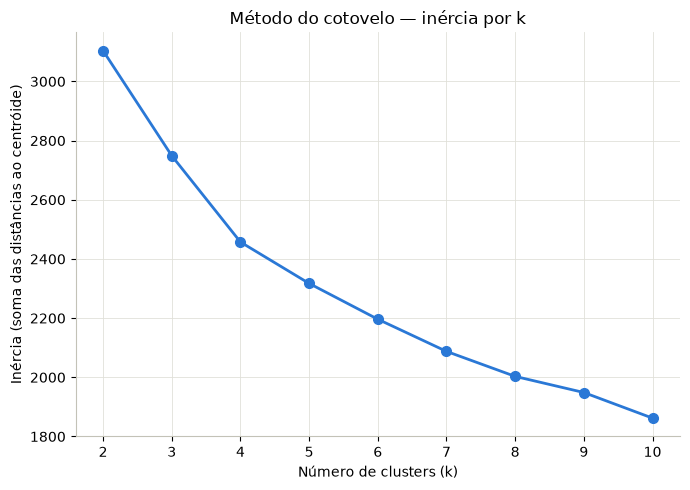

In [2358]:
### Método do cotovelo: procure o k onde a queda da inércia desacelera — dali pra frente,
### cada cluster a mais compra pouca redução de distância.

plt.figure(figsize=(7, 5))
plt.plot(metricas['k'], metricas['inercia'],
         marker='o', markersize=7, color='#2a78d6', linewidth=2)
plt.title('Método do cotovelo — inércia por k')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia (soma das distâncias ao centróide)')
plt.xticks(list(valores_k))

ax = plt.gca()
ax.grid(True, color='#e1e0d9', linewidth=0.6)
ax.set_axisbelow(True)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
for lado in ('left', 'bottom'):
    ax.spines[lado].set_color('#c3c2b7')

plt.tight_layout()
plt.show()

In [2359]:
k_escolhido = 4

kmeans = KMeans(n_clusters=k_escolhido, n_init=20, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

print(f'k = {k_escolhido}')
print(pd.Series(clusters_kmeans).value_counts().sort_index().to_string())

k = 4
0    115
1    161
2     74
3     94


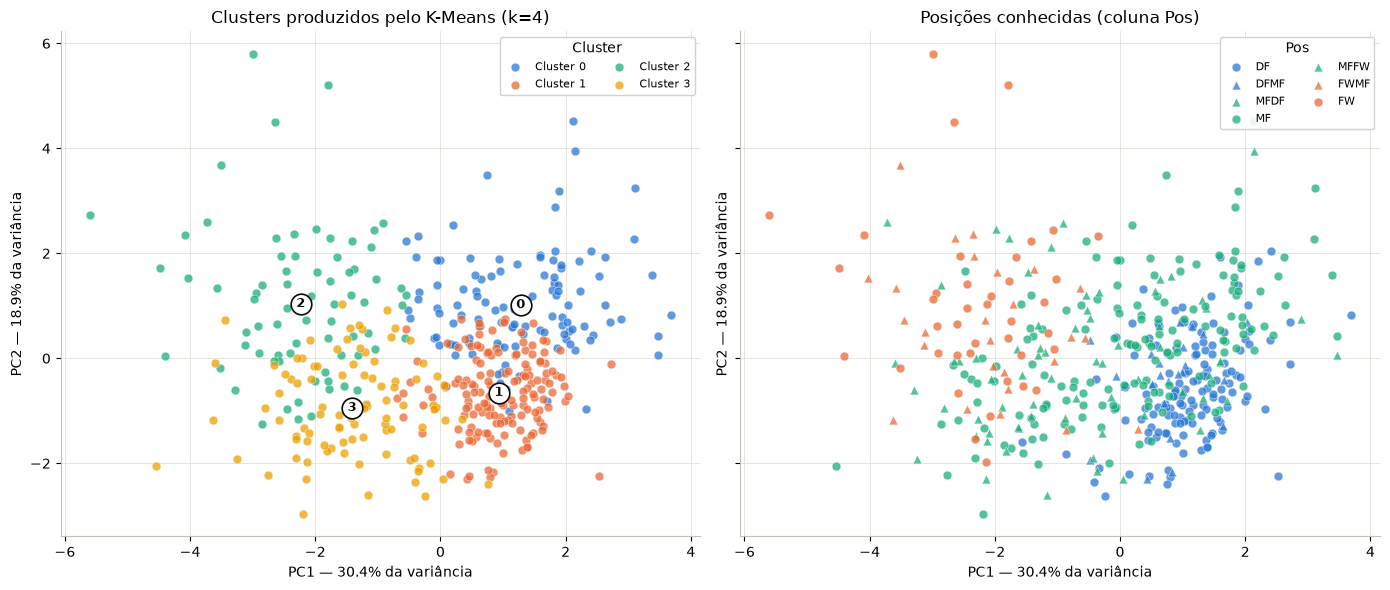

k = 4  |  variância representada no plano: 49.2%


cluster,0,1,2,3
Pos,,,,
DF,28,96,0,10
DFMF,11,12,0,3
MFDF,9,11,0,2
MF,61,39,7,43
MFFW,5,2,14,25
FWMF,0,1,17,8
FW,1,0,36,3


cluster,0,1,2,3
Pos,,,,
DF,20.9,71.6,0.0,7.5
DFMF,42.3,46.2,0.0,11.5
MFDF,40.9,50.0,0.0,9.1
MF,40.7,26.0,4.7,28.7
MFFW,10.9,4.3,30.4,54.3
FWMF,0.0,3.8,65.4,30.8
FW,2.5,0.0,90.0,7.5


In [2360]:
### A nuvem projetada em PC1 x PC2, colorida duas vezes: por cluster e por Pos real.
### Virou função porque vamos olhar o mesmo par de gráficos para vários k.

pos = stats_df['Pos'].to_numpy()

# A cor identifica o grupo, mas nunca sozinha: no painel 1 os centróides são
# rotulados (se k > 8 as cores se repetem, o número é que dá a identidade);
# no painel 2 o marcador separa posição pura de híbrida.
cores_cluster = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
                 '#e87ba4', '#008300', '#4a3aa7', '#e34948']
cores_pos = {'GK': '#4a3aa7', 'DF': '#2a78d6', 'MF': '#1baf7a', 'FW': '#eb6834'}
ordem_pos = ['GK', 'DF', 'DFMF', 'MFDF', 'MF', 'MFFW', 'FWMF', 'FW']


def comparar_clusters_vs_pos(k):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    rotulos = km.fit_predict(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # --- Painel 1: clusters produzidos pelo K-Means ---
    for c in np.unique(rotulos):
        plot = rotulos == c
        axes[0].scatter(
            X_pca[plot, 0], X_pca[plot, 1],
            color=cores_cluster[c % len(cores_cluster)], label=f'Cluster {c}',
            alpha=0.75, s=40, edgecolors='#fcfcfb', linewidths=0.4
        )

    for c, (cx, cy) in enumerate(pca.transform(km.cluster_centers_)):
        axes[0].scatter(cx, cy, s=220, color='white',
                        edgecolors='#0b0b0b', linewidths=1.2, zorder=5)
        axes[0].text(cx, cy, str(c), ha='center', va='center',
                     fontsize=9, fontweight='bold', color='#0b0b0b', zorder=6)

    axes[0].set_title(f'Clusters produzidos pelo K-Means (k={k})')
    axes[0].legend(title='Cluster', fontsize=8, ncol=2, loc='upper right', framealpha=0.9)

    # --- Painel 2: posições conhecidas ---
    # Cor = posição primária (GK/DF/MF/FW) · marcador = posição pura (o) vs híbrida (^)
    for classe in ordem_pos:
        plot = pos == classe
        if not plot.any():
            continue
        axes[1].scatter(
            X_pca[plot, 0], X_pca[plot, 1],
            color=cores_pos[classe[:2]], marker='^' if len(classe) > 2 else 'o',
            label=classe, alpha=0.75, s=40, edgecolors='#fcfcfb', linewidths=0.4
        )

    axes[1].set_title('Posições conhecidas (coluna Pos)')
    axes[1].legend(title='Pos', fontsize=8, ncol=2, loc='upper right', framealpha=0.9)

    for ax in axes:
        ax.set_xlabel(f'PC1 — {variancia[0]:.1f}% da variância')
        ax.set_ylabel(f'PC2 — {variancia[1]:.1f}% da variância')
        ax.grid(True, color='#e1e0d9', linewidth=0.6)
        ax.set_axisbelow(True)
        for lado in ('top', 'right'):
            ax.spines[lado].set_visible(False)
        for lado in ('left', 'bottom'):
            ax.spines[lado].set_color('#c3c2b7')

    plt.tight_layout()
    plt.show()

    print(f'k = {k}  |  variância representada no plano: {variancia.sum():.1f}%')

    # Contagem absoluta, com Pos nas linhas
    tabela = pd.crosstab(pd.Series(pos, name='Pos'), pd.Series(rotulos, name='cluster'))
    tabela = tabela.reindex([c for c in ordem_pos if c in tabela.index])
    display(tabela)

    # Mesma tabela em % da linha — é aqui que dá para ver quais classes de Pos colapsam
    display((100 * tabela.div(tabela.sum(axis=1), axis=0)).round(1))


comparar_clusters_vs_pos(k_escolhido)

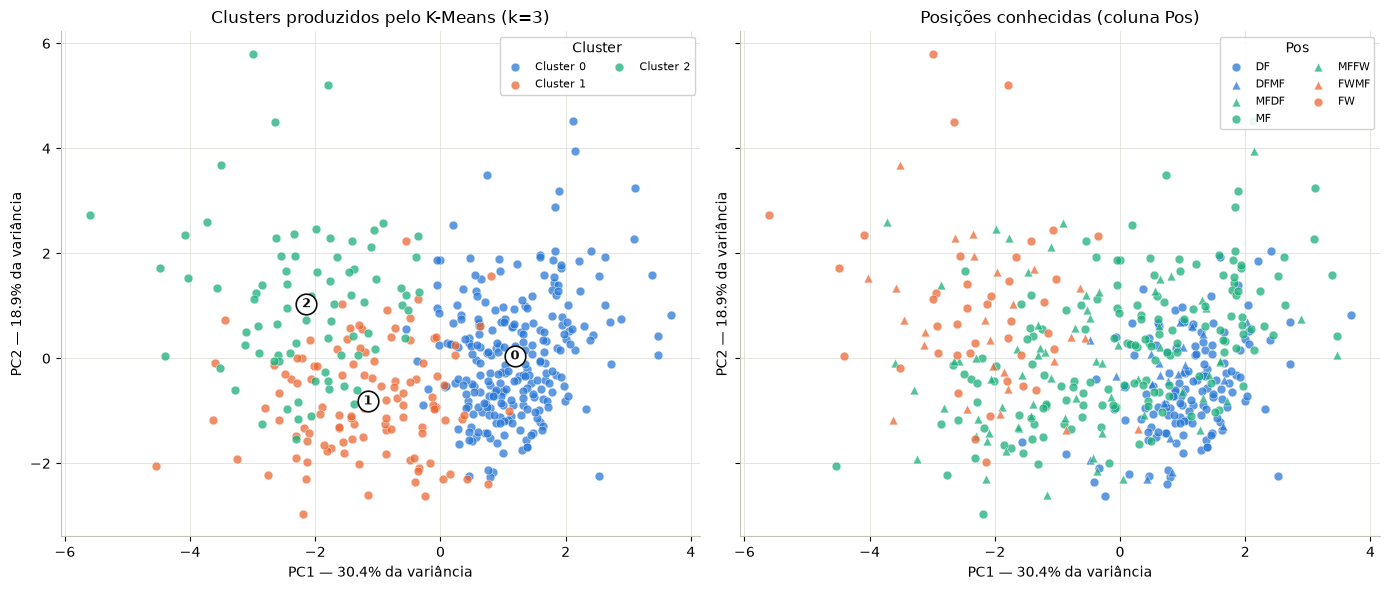

k = 3  |  variância representada no plano: 49.2%


cluster,0,1,2
Pos,,,
DF,120,14,0
DFMF,22,4,0
MFDF,16,6,0
MF,91,51,8
MFFW,2,28,16
FWMF,1,8,17
FW,0,2,38


cluster,0,1,2
Pos,,,
DF,89.6,10.4,0.0
DFMF,84.6,15.4,0.0
MFDF,72.7,27.3,0.0
MF,60.7,34.0,5.3
MFFW,4.3,60.9,34.8
FWMF,3.8,30.8,65.4
FW,0.0,5.0,95.0


In [2361]:
comparar_clusters_vs_pos(3)

### Analisando a mediana de minutos dos clusters para ter certeza que não tem um cluster formado essencialmente por reservas (cluster de reservas)

In [2362]:
mediana_geral = stats_df['Min'].median()
print(f'mediana de minutos do dataset inteiro: {mediana_geral:.0f}\n')


def perfil_minutagem(k):
    rotulos = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X_scaled)
    agrupado = stats_df.assign(_cluster=rotulos).groupby('_cluster')

    perfil = pd.DataFrame({
        'n': agrupado.size(),
        'Min mediana': agrupado['Min'].median().round(0),
        'razao vs geral': (agrupado['Min'].median() / mediana_geral).round(2),
        '% abaixo de 450min': (100 * agrupado['Min'].apply(lambda s: (s < 450).mean())).round(1),
        'Pos dominante': agrupado['Pos'].agg(lambda s: s.mode()[0]),
    })
    perfil.index.name = f'cluster (k={k})'

    return perfil.sort_values('Min mediana')


for k_teste in [3, 4, 5]:
    display(perfil_minutagem(k_teste))

mediana de minutos do dataset inteiro: 1277



,n,Min mediana,razao vs geral,% abaixo de 450min,Pos dominante
cluster (k=3),,,,,
2,79,1168.0,0.91,0.0,FW
1,113,1259.0,0.99,0.0,MF
0,252,1310.0,1.03,0.0,DF


,n,Min mediana,razao vs geral,% abaixo de 450min,Pos dominante
cluster (k=4),,,,,
2,74,1142.0,0.89,0.0,FW
0,115,1210.0,0.95,0.0,MF
3,94,1246.0,0.98,0.0,MF
1,161,1419.0,1.11,0.0,DF


,n,Min mediana,razao vs geral,% abaixo de 450min,Pos dominante
cluster (k=5),,,,,
4,72,1146.0,0.90,0.0,FW
3,83,1150.0,0.90,0.0,MF
0,97,1210.0,0.95,0.0,MF
2,70,1296.0,1.02,0.0,MF
1,122,1429.0,1.12,0.0,DF
